## Initialization

In [5]:
import sys
sys.path.append('../src') # add the source code to the path

# These are the main files in MinScaffold/src/

import Driver
import Geometry
import Scaffold

# These libraries are used throughout the code

import math
import numpy as np
from random import random
import networkx as nx
import pickle as pk
import matplotlib.pyplot as plt
import shapely
from shapely.geometry import Polygon
import geopandas as gpd
import pandas as pd

## (1) Read in distance matrix

In [6]:
## My data: the grocery stores
# Load in different distance measures
city_path = '../Distance Matrix Construction/'
city_code = 'dal'

# All the distance matrices to consider
dist_type_list = ['geodesic','walk','drive_osm','drive_gmaps_TrafUnaware']

dist_type = dist_type_list[0]

city_fname = f'{city_code}_{dist_type}_distance_data.npz'
with np.load(city_path+city_fname) as data:
    if dist_type == 'walk':
        W = data['dal_walk_distance_seconds']
        walk_speed = data['walk_speed']
    elif dist_type == 'geodesic':
        W = data['dal_geodesic_distance_seconds']
        walk_speed = data['walk_speed']

# Symmetrize
W = W+np.transpose(W)

# Put in units of minutes
W = W/60

In [7]:
#cut off data to avoid overly dense distance matrix
if dist_type == 'walk':
    Wsave = W
    W = np.round((W<180)*W)
    W = W - np.diag(np.diag(W))
elif dist_type == 'geodesic':
    Wsave = W
    W = np.round((W<120)*W)
    W = W - np.diag(np.diag(W))
elif (dist_type[0:5] == 'drive'):
    Wsave = W
    W = np.round((W<15)*W,1)
    W = W - np.diag(np.diag(W))

### (1a) Read in resource locations; organize Lat,Long coordinates

In [8]:
data_topdir = '../Data_Local/'

#
# Resource of interest
resource_dir  = data_topdir+'Food access_updated/'
resource_fname = 'geo_export_872fcb6c-fbde-4264-ae77-8858a604ed0e.shp'

# ZIP codes: good for visualization
zip_dir = data_topdir+'Zip/'
zip_fname = 'dal_tx_zip.shp'

# Population; Census blocks or others
block_dir = '../Data_Local/Block/'
block_fname = 'dal_tx_block.shp'

# GDF with grocery locations
# "polls" is a holdover from the previous paper (on polling locations)
polls_df = gpd.read_file(resource_dir+resource_fname)

In [9]:
P = np.zeros((polls_df.shape[0],2))
NV = polls_df.shape[0]
for j1 in range(polls_df.shape[0]):
    P[j1,:]=[polls_df.loc[j1,'geometry'].x, polls_df.loc[j1,'geometry'].y] 

### (Optional) Network Visualization

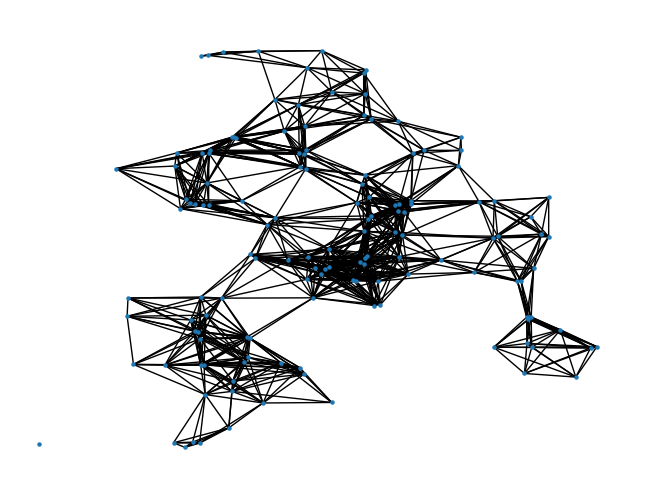

In [10]:
G = nx.Graph(W) # create a nx object

# Plot the input weighted graph.
nx.draw(G, pos=P, node_size=5)

## (2) Use MinScaffold to compute homology over filtration

### Creating Minimal Scaffold

In [11]:
epsList = Geometry.genFullEpsList(W) # create list of filtration parameters

In [ ]:
#print(epsList)

In [12]:
# compute minimal generators for each filtration value
F = Driver.getFiltrBasis(W, epsList, Draws=False, parallel=False, monitor=None)

In [13]:
numCyc = [x[1].card() for x in F.Elements]

epsLev = [x[0] for x in F.Elements]

In [14]:
#compute the adjacency matrix of the minimal scaffold.
S = Scaffold.frequency_Scaffold(F , len(P))

In [15]:
if False:
    Scaf = nx.from_numpy_array(S, parallel_edges=False)
    nx.draw(Scaf,pos=P, node_size=5)

### Exploring Bases

In [16]:
# Create a list of homology bases
Bas = []
for (step,B) in F.Elements: 
    Bas.append(B) # store the basis, discarding the filtration step value

In [17]:
# Load in zip code file to plot underneath resource locations
city_df = gpd.read_file(zip_dir+zip_fname)

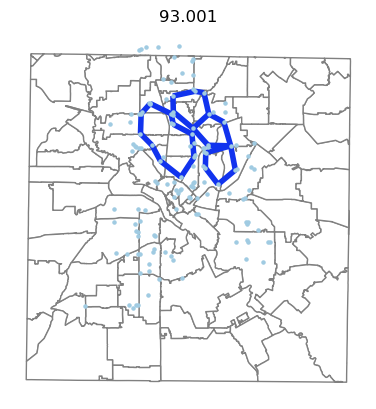

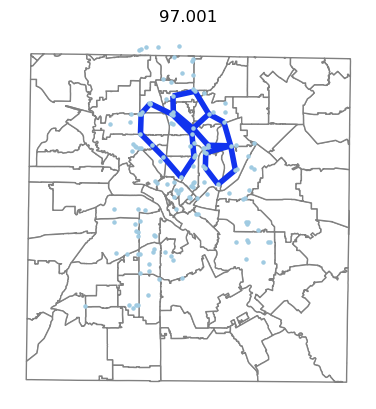

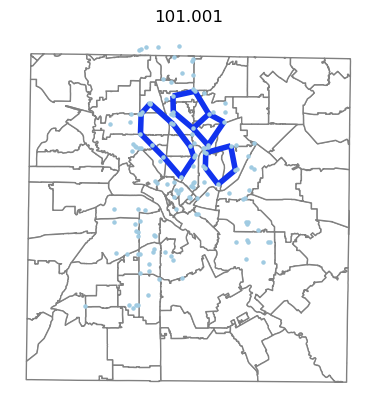

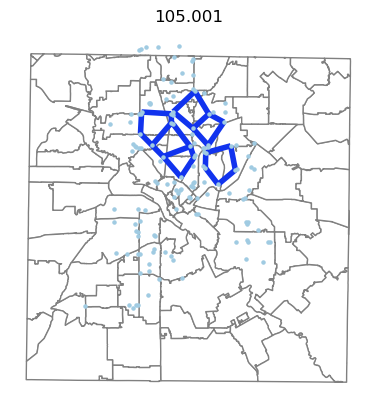

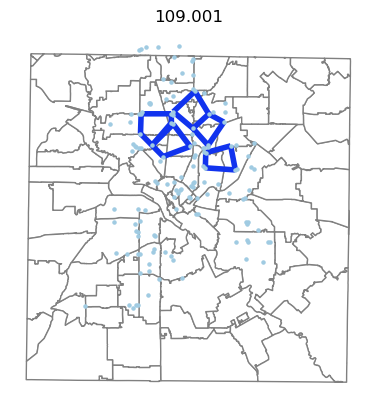

In [18]:
#Print selected minimal generators

np.set_printoptions(threshold=np.inf)
indices = 90+4*np.array(range(5))

colors = [1,2,3]
options = {
    "node_color": "#A0CBE2",
    "edge_color": "#1133EE",
    "width": 4,
    "edge_cmap": plt.cm.Blues,
    "with_labels": False,
}
edge_color_list = ["#1133EE","#6699EE","#AABBEE"]

# Depending on the length of the filtration, choose a suitable step that contains nontrivial homology
for j1 in range(len(indices)):
    fig , ax1= plt.subplots()
    city_df.plot(ax=ax1, color='white', edgecolor='grey')
    #options["edge_color"]=edge_color_list[np.mod(j1,3)]
    
    whichB = indices[j1]
    B = Bas[whichB]
    #print(P)
    #print(M)
    #print(whichB)
    M = Scaffold.matrix_Basis( B , len(P) , np.array(F.get_edgeList()) )
    
    
    # Plot the basis at the given step, using the layout object as done above
    nx.draw( nx.Graph(M) , pos = P , node_size=5, **options, ax=ax1)
    S = [nx.Graph(M).subgraph(c).copy() for c in nx.connected_components(nx.Graph(M))]
    plt.title(epsLev[whichB])
    #plt.savefig(f'../Cycles_Dallas/dal_tx_MinCycles_{dist_type}_{str(whichB)}.jpeg', \
                #bbox_inches="tight", dpi = 300)
    plt.show()
    

In [19]:

if False:
    # Print selected minimal generators
    i = 0
    for (e,B) in F.Elements:
        i += 1
        if np.mod(i,10)==1:
            fig , ax1= plt.subplots()
            M = Scaffold.matrix_Basis( B , len(P) , np.array(F.get_edgeList()) )
            nx.draw( nx.Graph(M) , pos = P , node_size=5, ax=ax1 )
            plt.title(epsLev[i])
            plt.show()

## Visualizing Holes using Shapely

In [25]:
# In polygons_list, store list of vertices that make up each hole

np.set_printoptions(threshold=np.inf)
indices = range(len(epsList))

polygons_list = [];
for j1 in range(len(indices)):
    whichB = indices[j1]
    B = Bas[whichB]
    M = Scaffold.matrix_Basis( B , len(P) , np.array(F.get_edgeList()) )
    S = [nx.Graph(M).subgraph(c).copy() for c in nx.connected_components(nx.Graph(M))]
    polygons = []
    for component in S:
        if len(component.nodes) > 1:
            path = []
            cycle = nx.find_cycle(component)
            for edge in cycle: 
                path.append(edge[0])
            polygons.append(path)
    polygons_list.append(polygons)

In [20]:
# For names/locations of data files, see first few cells
block_df = gpd.read_file(block_dir+block_fname)
groc_df  = gpd.read_file(resource_dir+resource_fname)
zip_df = gpd.read_file(zip_dir+zip_fname)

In [21]:
sqm_to_sqmi_convert = 2589988

# Assuming "ALAND' and "POP20" are accurate:
block_df['PopDens']=block_df['POP20']/block_df['ALAND20']*sqm_to_sqmi_convert

In [21]:
# Coordinate systems
meters_per_mile = 1609.34
crs = {
    'census': 'EPSG:4269'  , # degrees - used by Census
    'projected': 'EPSG:3083',         # projected; needed for maup
    'area'  : 'ESRI:102003', # meters
    'length': 'ESRI:102005', # meters
}
'''
EPSG:3083
Coordinate System: 	
Cartesian 2D CS. Axes: easting, northing (X,Y). 
Orientations: east, north. UoM: m.Open
Base CRS: 	
NAD83Open
Conversion: 	
Texas Centric Albers Equal Area
'''

'\nEPSG:3083\nCoordinate System: \t\nCartesian 2D CS. Axes: easting, northing (X,Y). \nOrientations: east, north. UoM: m.Open\nBase CRS: \t\nNAD83Open\nConversion: \t\nTexas Centric Albers Equal Area\n'

In [22]:
# Project all into CRS
block_df.geometry = block_df.geometry.to_crs(crs['projected'])
groc_df.geometry = groc_df.geometry.to_crs(crs['projected'])

In [23]:
geo_walk_conversion_rate = 1.14 # adjustment factor to compensate for walking distance being longer than geodesic distance

In [93]:
# Calculate population in holes for a few indices

# do we want to do visuals?
do_visuals = False

allCycles = pd.DataFrame(data=[], columns=['poly','geometry'])

indices = range(len(epsList))
for i in indices:
    print(epsList[i])
    if dist_type == 'walk':
        radius_serv_area = epsList[i] * 60 * walk_speed / (4 * geo_walk_conversion_rate)
    elif dist_type == 'geodesic':
        radius_serv_area = epsList[i] * 60 * walk_speed / 4
    print(radius_serv_area)

    # Create service areas of all grocery stores, with the given radius
    service_areas = groc_df.geometry.buffer(radius_serv_area)
    service_areas_all = service_areas.union_all()
    service_area_holes = block_df.geometry.intersection(service_areas_all)

    # The rest of the area NOT included in the service areas
    county_with_holes = block_df['geometry'].difference(service_area_holes)
    if do_visuals:
        county_with_holes.plot()
    #county_with_holes_union = county_with_holes

    # Keep each of the "swiss cheese" shapes
    min_cycle_hole_df = pd.DataFrame(data=[], columns=['eps','which_cycle','poly','geometry'])

    # to count which cycle
    which_cycle=0
    for poly in polygons_list[i]:
        # "poly" contains the Dataframe indices
        groc_df_lim = groc_df.loc[poly]

        # Create a polygon from the vertices
        min_cycle_area = Polygon(groc_df_lim['geometry'])
        list_of_areas = [min_cycle_area]
        # Also get services areas from each vertex on cycle.
        # Put all in a single list, for visualization
        for l in poly:
            service_area_pt = groc_df.loc[l].geometry.buffer(radius_serv_area)
            list_of_areas.append(service_area_pt)

        if False:
            # Union of all service areas from vertices
            service_areas_lim = groc_df_lim.geometry.buffer(radius_serv_area)
            service_areas_all_lim = service_areas_lim.union_all()

            ## ???
            service_area_holes_lim = block_df.geometry.intersection(service_areas_all_lim)
            #min_cycle_area = Polygon(groc_df_lim['geometry'])
        
        min_cycle_df = gpd.GeoDataFrame(data = [[poly]], \
                                geometry=gpd.GeoSeries(min_cycle_area),\
                               crs=crs['projected'])
        min_cycle_df=min_cycle_df.rename(columns={0:'Cycle vertices'})
        #shapes = gpd.GeoSeries([min_cycle_area, service_areas_all_lim])

        if do_visuals:
            # List of the shapes to illustrate how "service areas" overlap with the cycle
            shapes = gpd.GeoSeries(list_of_areas)
            shapes.plot(color='purple',alpha = 0.3,edgecolor='k')
        
        #min_cycle_df.plot()
        if False:
            # Why do we do this?
            county_with_holes_union = county_with_holes_union.geometry.union(min_cycle_df)

        # This is intersection with the cycle area AND the service areas
        # note it is ALL service areas, not just ones on the boundary. So its shape may
        # be slightly different than the illustration with the polygon + circles
        #
        # (why named "cycle_holes"? because we will delete them from the cycle)
        cycle_holes = min_cycle_df.geometry.intersection(service_areas_all)

        # Now subtract (via set difference, those intersections from the area of the cycle)
        cycle_with_holes = min_cycle_df.difference(cycle_holes)
        if do_visuals:
            cycle_with_holes.plot()

        newrow = pd.DataFrame(data={'which_cycle':which_cycle, 'poly':[poly], 'geometry': [cycle_with_holes[0]]})
        min_cycle_hole_df = pd.concat([min_cycle_hole_df,newrow],ignore_index=True)

        which_cycle=which_cycle+1
        
    min_cycle_hole_df['eps']=epsList[i]

    allCycles = pd.concat([allCycles,min_cycle_hole_df],ignore_index=True)

0.001
0.0213
3.001
63.921299999999995
4.001
85.22130000000001
5.001
106.5213
6.001
127.8213
7.001
149.1213
8.001
170.42129999999997
9.001
191.72129999999999
10.001
213.02129999999997
11.001
234.32129999999998
12.001
255.62129999999996
13.001
276.9213
15.001
319.52129999999994
16.001
340.8213
17.001
362.1213
18.001
383.42130000000003
19.001
404.72130000000004
20.001
426.02130000000005
21.001
447.32130000000006
22.001
468.6213
23.001
489.92130000000003
24.001
511.22130000000004
25.001
532.5213
26.001
553.8213000000001
27.001
575.1213
28.001
596.4213000000001
29.001
617.7213
30.001
639.0213
31.001
660.3213000000001
32.001
681.6212999999999
33.001
702.9213
34.001
724.2212999999999
35.001
745.5213
36.001
766.8213
37.001
788.1212999999999
38.001
809.4213
39.001
830.7212999999999
40.001
852.0212999999999
41.001
873.3213
42.001
894.6212999999999
43.001
915.9213
44.001
937.2212999999999
45.001
958.5212999999999
46.001
979.8213
47.001
1001.1212999999999
48.001
1022.4213
49.001
1043.7213
50.001
1

In [94]:
tempdf=allCycles.set_index(['eps','which_cycle'])

In [95]:
tempdf

poly  \
eps     which_cycle                           
36.001  0              [65, 57, 82, 83, 68]   
37.001  0              [65, 57, 82, 83, 68]   
38.001  0                  [65, 68, 83, 82]   
39.001  0            [104, 45, 126, 13, 79]   
        1                  [65, 68, 83, 82]   
...                                     ...   
117.001 2                  [16, 41, 43, 64]   
118.001 0                 [128, 6, 111, 68]   
        1                  [16, 41, 43, 64]   
119.001 0                  [16, 41, 43, 64]   
120.001 0                  [16, 41, 43, 64]   

                                                              geometry  
eps     which_cycle                                                     
36.001  0            POLYGON ((1802051.6318583644 7642055.712069485...  
37.001  0            POLYGON ((1802128.8812544232 7642073.21705001,...  
38.001  0            POLYGON ((1802209.542120428 7642082.759266171,...  
39.001  0            POLYGON ((1800512.9578864176 7635204.681799128...  
        1            POLYGON ((1802213.6975442872 7642103.649992643...  
...                                                                ...  
117.001 2            POLYGON ((1800989.3791949388 7648447.434801749...  
118.001 0            POLYGON ((1798647.0617756364 7643344.663977534...  
        1            POLYGON ((1801009.76202409 7648453.617865375, ...  
119.001 0            POLYGON ((1801030.144853241 7648459.800929001,...  
120.001 0            POLYGON ((1801111.4758688686 7648222.665192997...  

[181 rows x 2 columns]

In [96]:
min_cycle_hole_gdf = gpd.GeoDataFrame(tempdf,geometry=tempdf['geometry'])

In [97]:
min_cycle_hole_gdf

poly  \
eps     which_cycle                           
36.001  0              [65, 57, 82, 83, 68]   
37.001  0              [65, 57, 82, 83, 68]   
38.001  0                  [65, 68, 83, 82]   
39.001  0            [104, 45, 126, 13, 79]   
        1                  [65, 68, 83, 82]   
...                                     ...   
117.001 2                  [16, 41, 43, 64]   
118.001 0                 [128, 6, 111, 68]   
        1                  [16, 41, 43, 64]   
119.001 0                  [16, 41, 43, 64]   
120.001 0                  [16, 41, 43, 64]   

                                                              geometry  
eps     which_cycle                                                     
36.001  0            POLYGON ((1802051.632 7642055.712, 1801976.47 ...  
37.001  0            POLYGON ((1802128.881 7642073.217, 1802051.632...  
38.001  0            POLYGON ((1802209.542 7642082.759, 1802130.969...  
39.001  0            POLYGON ((1800512.958 7635204.682, 1800524.405...  
        1            POLYGON ((1802213.698 7642103.65, 1802133.057 ...  
...                                                                ...  
117.001 2            POLYGON ((1800989.379 7648447.435, 1800952.215...  
118.001 0            POLYGON ((1798647.062 7643344.664, 1798892.883...  
        1            POLYGON ((1801009.762 7648453.618, 1800987.4 7...  
119.001 0            POLYGON ((1801030.145 7648459.801, 1801022.584...  
120.001 0            POLYGON ((1801111.476 7648222.665, 1801054.433...  

[181 rows x 2 columns]

In [98]:
# POPULATION INSIDE HOLE
#
# This may go through ALL holes with any filtration value
# I kept intermediate values (like intersection area, etc.) in case we want to look more closely
#    at the results
# Have not attempted to optimize in speed or efficiency
# 
interarea = pd.Series(index=min_cycle_hole_gdf.index)
interpop = pd.Series(index=min_cycle_hole_gdf.index)

for cycleind,cyclerow in min_cycle_hole_gdf.iterrows():
    print(cycleind)
    print(cyclerow)
    # For a single hole, find all non-empty intersections with Census blocks
    mytemp=cyclerow['geometry'].intersection(block_df['geometry'])
    actualInt = mytemp[~mytemp.is_empty]

    # Iterate through Census blocks. For each track area, intersection area, populations
    actualInt=pd.DataFrame(actualInt)
    blkarea = pd.Series(index=actualInt.index)
    intarea = pd.Series(index=actualInt.index)
    blkpop = pd.Series(index=actualInt.index)

    for index, value in actualInt.iterrows():
        blkarea[index]=block_df.loc[index].geometry.area
        intarea[index]=actualInt.loc[index].geometry.area
        blkpop[index]=block_df.loc[index]['POP20']

    # Put back into "actualInt" dataframe
    actualInt['Block area']=blkarea
    actualInt['Intersection area']=intarea
    actualInt['Block pop']=blkpop

    actualInt['Intersection pop']= blkpop*intarea/blkarea

    interpop[cycleind]=actualInt['Intersection pop'].sum()
    interarea[cycleind]=actualInt['Intersection area'].sum()

min_cycle_hole_gdf['Population']= interpop
min_cycle_hole_gdf['Area']= interarea


(36.001, 0)
poly                                     [65, 57, 82, 83, 68]
geometry    POLYGON ((1802051.6318583644 7642055.712069485...
Name: (36.001, 0), dtype: object
(37.001, 0)
poly                                     [65, 57, 82, 83, 68]
geometry    POLYGON ((1802128.8812544232 7642073.21705001,...
Name: (37.001, 0), dtype: object
(38.001, 0)
poly                                         [65, 68, 83, 82]
geometry    POLYGON ((1802209.542120428 7642082.759266171,...
Name: (38.001, 0), dtype: object
(39.001, 0)
poly                                   [104, 45, 126, 13, 79]
geometry    POLYGON ((1800512.9578864176 7635204.681799128...
Name: (39.001, 0), dtype: object
(39.001, 1)
poly                                         [65, 68, 83, 82]
geometry    POLYGON ((1802213.6975442872 7642103.649992643...
Name: (39.001, 1), dtype: object
(40.001, 0)
poly                                   [104, 45, 126, 13, 79]
geometry    POLYGON ((1800653.1671655204 7635466.717216074...
Name: (40.001, 0), 

In [100]:
min_cycle_hole_gdf

poly  \
eps     which_cycle                           
36.001  0              [65, 57, 82, 83, 68]   
37.001  0              [65, 57, 82, 83, 68]   
38.001  0                  [65, 68, 83, 82]   
39.001  0            [104, 45, 126, 13, 79]   
        1                  [65, 68, 83, 82]   
...                                     ...   
117.001 2                  [16, 41, 43, 64]   
118.001 0                 [128, 6, 111, 68]   
        1                  [16, 41, 43, 64]   
119.001 0                  [16, 41, 43, 64]   
120.001 0                  [16, 41, 43, 64]   

                                                              geometry  \
eps     which_cycle                                                      
36.001  0            POLYGON ((1802051.632 7642055.712, 1801976.47 ...   
37.001  0            POLYGON ((1802128.881 7642073.217, 1802051.632...   
38.001  0            POLYGON ((1802209.542 7642082.759, 1802130.969...   
39.001  0            POLYGON ((1800512.958 7635204.682, 1800524.405...   
        1            POLYGON ((1802213.698 7642103.65, 1802133.057 ...   
...                                                                ...   
117.001 2            POLYGON ((1800989.379 7648447.435, 1800952.215...   
118.001 0            POLYGON ((1798647.062 7643344.664, 1798892.883...   
        1            POLYGON ((1801009.762 7648453.618, 1800987.4 7...   
119.001 0            POLYGON ((1801030.145 7648459.801, 1801022.584...   
120.001 0            POLYGON ((1801111.476 7648222.665, 1801054.433...   

                      Population           Area  
eps     which_cycle                              
36.001  0            1562.588238  250399.749243  
37.001  0            1236.373350  196252.594446  
38.001  0             954.976039  150256.414095  
39.001  0             810.478488  198801.887982  
        1             707.301460  111371.193872  
...                          ...            ...  
117.001 2             474.421634  322879.073636  
118.001 0             131.243391  168831.056942  
        1             367.325523  271991.700271  
119.001 0             277.311727  225639.925088  
120.001 0             196.968437  183718.063563  

[181 rows x 4 columns]

In [101]:
# Total # of people inconvenienced for this specific filtration value
min_cycle_hole_gdf['Population'].groupby(['eps']).sum()

eps
36.001     1562.588238
37.001     1236.373350
38.001      954.976039
39.001     1517.779948
40.001     1007.335142
              ...     
116.001     845.772215
117.001     648.516627
118.001     498.568914
119.001     277.311727
120.001     196.968437
Name: Population, Length: 84, dtype: float64